In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/kaggle/input/datasets/harshadapatil31/student-performance-and-study-habits-dataset/student_performance_dataset.csv")
df.shape

(1000, 12)

In [3]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   student_id                  1000 non-null   int64  
 1   gender                      1000 non-null   object 
 2   study_time_hours            1000 non-null   float64
 3   attendance_percent          1000 non-null   float64
 4   sleep_hours                 1000 non-null   float64
 5   parental_education          898 non-null    object 
 6   internet_access             1000 non-null   object 
 7   extracurricular_activities  1000 non-null   object 
 8   part_time_job               1000 non-null   object 
 9   previous_grade              1000 non-null   float64
 10  final_exam_score            1000 non-null   float64
 11  final_grade                 1000 non-null   object 
dtypes: float64(5), int64(1), object(6)
memory usage: 93.9+ KB


#### determing if the student is at risk of bad grade based on current grade,i.e, 'D', 'F'

In [5]:
df['at_risk'] = df['final_grade'].isin(['D','F']).astype('int') 

### Feature 1: Academic momentum

#### Instead of using the previous grades, we define our own academic momentum to divide the students into levels - high, medium, poor

In [6]:
def academic_momentum(grade):
    if grade>=80:
        return 'excellent'
    elif grade>=60:
        return 'average'
    else:
        return 'poor'

In [7]:
df['academic_level'] = df['final_exam_score'].apply(academic_momentum)

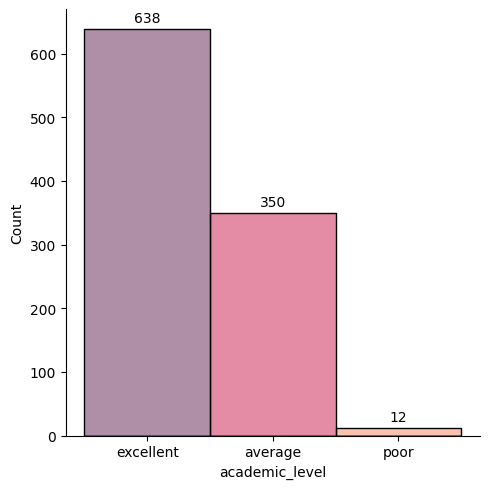

In [8]:
g = sns.displot(df, x='academic_level', binwidth=1, discrete=True, palette='rocket', hue='academic_level', legend=False)

for ax in g.axes.flat:
    for container in ax.containers:
        labels = [f'{v.get_height():.0f}' if v.get_height() > 0 else '' for v in container]
        ax.bar_label(container, labels=labels, padding=3)

plt.show()


## Feature 2: Attendance Risk

In [9]:
def attendance_risk(x):
    if x < 60:
        return "Critical"
    elif x < 75:
        return "Moderate"
    else:
        return "Healthy"

In [10]:
df['attendance_risk_level'] = df['attendance_percent'].apply(attendance_risk)

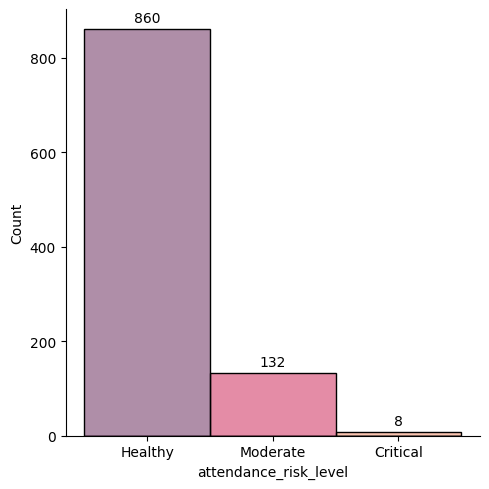

In [11]:
g = sns.displot(df, x='attendance_risk_level', binwidth=1, discrete=True, palette='rocket', hue='attendance_risk_level', legend=False)

for ax in g.axes.flat:
    for container in ax.containers:
        labels = [f'{v.get_height():.0f}' if v.get_height() > 0 else '' for v in container]
        ax.bar_label(container, labels=labels, padding=3)

plt.show()


## Feature 3: Sleep risk

In [12]:
df['sleep_deviation'] = abs(df['sleep_hours'] - 7.5)


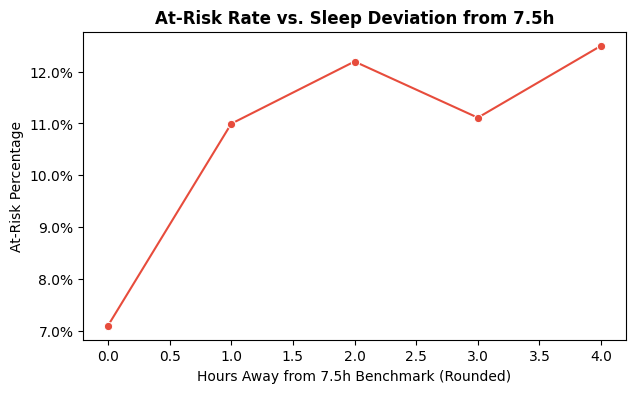

In [13]:
df['deviation_bin'] = df['sleep_deviation'].round()

plt.figure(figsize=(7, 4))
ax = sns.lineplot(
    data=df, 
    x='deviation_bin', 
    y='at_risk', 
    marker='o', 
    color='#e74c3c', 
    errorbar=None
)

import matplotlib.ticker as mtick
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_title("At-Risk Rate vs. Sleep Deviation from 7.5h", fontsize=12, fontweight='bold')
ax.set_xlabel("Hours Away from 7.5h Benchmark (Rounded)", fontsize=10)
ax.set_ylabel("At-Risk Percentage", fontsize=10)

plt.show()


## Feature 4: Workload Risk

In [14]:
threshold = 7.0

df['high_workload_low_sleep'] = (
    (df['part_time_job'].astype(str).str.strip().str.lower() == 'yes') & 
    (df['sleep_hours'] < threshold)
).astype(int)

df['high_workload_low_sleep'].value_counts()

high_workload_low_sleep
0    828
1    172
Name: count, dtype: int64

In [15]:
burnout_analysis = df.groupby('high_workload_low_sleep')['at_risk'].mean() * 100

print("--- Burnout Feature Validation ---")
print(f"Normal Student Risk Rate:  {burnout_analysis[0]:.1f}%")
print(f"Burnout Student Risk Rate: {burnout_analysis[1]:.1f}%")

--- Burnout Feature Validation ---
Normal Student Risk Rate:  7.1%
Burnout Student Risk Rate: 24.4%


## Feature 5: Engagement Score

Potential composite:

Engagement Score =
    Attendance +
    Study Time +
    Extracurricular Participation

In [16]:
# 1. Map text strings directly into a local variable
extracurricular_scaled = df['extracurricular_activities'].map({'Yes': 1.0, 'No': 0.0})

# 2. Complete Min-Max Scalers
attendance_min_max = (df['attendance_percent'] - df['attendance_percent'].min()) / (df['attendance_percent'].max() - df['attendance_percent'].min())
study_min_max = (df['study_time_hours'] - df['study_time_hours'].min()) / (df['study_time_hours'].max() - df['study_time_hours'].min())

# LINE 4 REMOVED: No more df['extracurricular_scaled'].astype(float) glitching!

# 3. Calculate composite metric using the valid local variable
df['engagement_score'] = (attendance_min_max + study_min_max + extracurricular_scaled) / 3

# 4. View results instantly
print(df[['attendance_percent', 'study_time_hours', 'engagement_score']].head())


   attendance_percent  study_time_hours  engagement_score
0                98.0               4.0          0.805426
1               100.0               6.3          0.921053
2                85.3               4.9          0.417909
3                77.5               2.6          0.592843
4                89.6               2.2          0.331199


/tmp/ipykernel_16/3115104381.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='final_grade', y='engagement_score', order=['A', 'B', 'C', 'D', 'F'], palette='viridis')


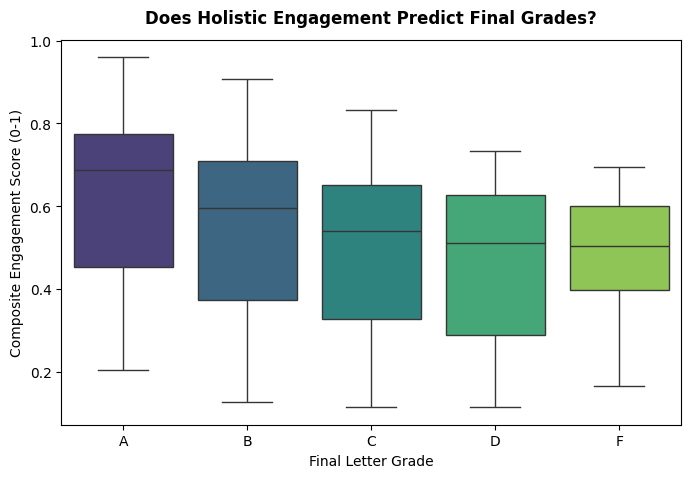

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
# Reindex ensures the x-axis reads naturally from best grade (A) to worst (F)
ax = sns.boxplot(data=df, x='final_grade', y='engagement_score', order=['A', 'B', 'C', 'D', 'F'], palette='viridis')

ax.set_title("Does Holistic Engagement Predict Final Grades?", fontweight='bold', pad=12)
ax.set_xlabel("Final Letter Grade")
ax.set_ylabel("Composite Engagement Score (0-1)")
plt.show()


* Grade A: The median line is high (~0.69). Because the box is slightly stretched downward toward the bottom whisker (left-skewed distribution), the mean will be slightly lower than the median, sitting around 0.64 – 0.66.
* Grade B: The median is at ~0.60. The box and whiskers are highly symmetrical, which means the distribution is balanced. For Grade B, the mean and median will be nearly identical, right around 0.58 – 0.60.
* Grade C: The median sits at ~0.54. The data stretches slightly more toward the lower end, meaning the mean will likely hover just below the median line, around 0.51 – 0.53.
* Grade D: The median is at ~0.51. Much like Grade B, it is relatively balanced from top to bottom, putting the mean very close to 0.49 – 0.51.
* Grade F: The median drops to ~0.50. However, notice that the lower whisker is significantly shorter than the top whisker. This indicates the data is right-skewed (stretched upward). The few students with higher engagement scores who still failed will pull the average up, making the mean higher than the median, sitting around 0.52 – 0.54.

In [18]:
df.head()

,student_id,gender,study_time_hours,attendance_percent,sleep_hours,parental_education,internet_access,extracurricular_activities,part_time_job,previous_grade,final_exam_score,final_grade,at_risk,academic_level,attendance_risk_level,sleep_deviation,deviation_bin,high_workload_low_sleep,engagement_score
0,1,Male,4.0,98.0,6.5,Bachelors,Yes,Yes,No,76.9,100.0,A,0,excellent,Healthy,1.0,1.0,0,0.805426
1,2,Female,6.3,100.0,5.7,High School,Yes,Yes,Yes,75.5,100.0,A,0,excellent,Healthy,1.8,2.0,1,0.921053
2,3,Male,4.9,85.3,7.9,Bachelors,Yes,No,Yes,88.5,97.3,A,0,excellent,Healthy,0.4,0.0,0,0.417909
3,4,Male,2.6,77.5,8.0,NaN,Yes,Yes,No,85.1,83.8,B,0,excellent,Healthy,0.5,0.0,0,0.592843
4,5,Male,2.2,89.6,4.6,Bachelors,Yes,No,Yes,61.8,68.3,D,1,average,Healthy,2.9,3.0,1,0.331199


In [19]:
df.to_csv('student_performance_dataset_cleaned.csv', index=False)

print("Dataset created..")

Dataset created..
